In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#helper function: for numbering images
def GetNumberString(x):
    assert type(x) == int
    x_str = str(x)
    assert len(x_str) <= 4 and x > 0
    if len(x_str) == 1:
        return "000" + x_str
    elif len(x_str) == 2:
        return "00" + x_str
    elif len(x_str) == 3:
        return "0" + x_str
    return x_str

In [3]:
#helper function: converting unruly filenames into a neatly formatted string
#with only underscore separations
def FormatFileName(fname):
    new_fname = ""
    for c in fname:
        if c == " " or c == ".":
            new_fname += "_"
        else:
            new_fname += c
    return new_fname[:-4]

In [4]:
data_dir = "/Users/jonathanzhu/nematostella_videos/vids/"
image_dir = "/Users/jonathanzhu/nematostella_videos/imgs/"
files = os.listdir(data_dir)
files

['wt 25c 3 dpf fert 04.24.2026.mov',
 'wt 25C 8 dpf celldish 04.01.2026.mov',
 'rpa bb 25C 6 dpf fert 04.24.2026.mov',
 'rpa aa 16C 5 dpf fert 04.10.2026.mov',
 'glw ac 16c 4 dpf fert 04.10.2026.mov',
 'wt 16C 3 dpf 03.27.2026 celldish.mov',
 'glw ac 25c 3 dpf fert 04.24.2026.mov',
 'rpa aa 16C 6 dpf movedtodish 03.30.2026.mov',
 'rpa aa 16C 5 dpf fert 04.24.2026.mov',
 'wt 16c 4 dpf fert 04.10.2026.mov',
 'glw ac 25C 2 dpf 03.26.2026.mov',
 'rpa bb 25C 6 dpf fert 04.10.2026.mov',
 'rpa bb 16C 8 dpf celldish 04.01.2026.mov',
 'glw ac 25c 7 dpf fert 04.10.2026.mov',
 'rpa aa 25C 8 dpf celldish 04.01.2026.mov',
 'rpa aa 25C 6 dpf fert 04.10.2026.mov',
 '.DS_Store',
 'rpa bb 16C 3 dpf movedtodish 03.27.2026.mov',
 'wt 25c 7 dpf fert 04.24.2026.mov',
 'rpa bb 16C 5 dpf fert 04.24.2026.mov',
 'rpa bb 16C 5 dpf fert 04.10.2026.mov',
 'rpa bb 25C 3 dpf 03.27.2026 celldish.mov',
 'wt 25c 7 dpf fert 04.10.2026.mov',
 'wt 25C 2 dpf 03.26.2026.mov',
 'rpa aa 16C 3 dpf 03.27.2026 celldish.mov',
 '

In [5]:
len(files)

102

In [329]:
file = files[102]
print(file)

cap = cv2.VideoCapture(data_dir + file)
print(cap.get(cv2.CAP_PROP_FPS))

fps = cap.get(cv2.CAP_PROP_FPS)
#frames_in_min = 1800
frames_in_min = int(fps * 60)
print(frames_in_min)

IndexError: list index out of range

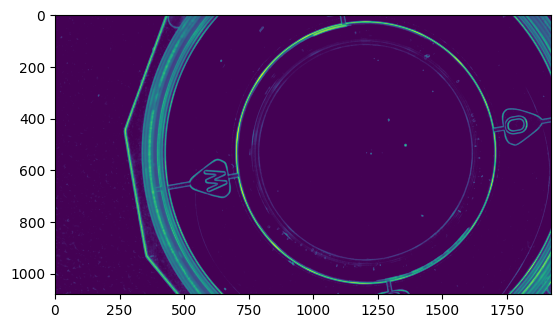

In [322]:
frames_in_six_secs = fps * 6
frame_num = 0
while frame_num < frames_in_six_secs:
    ret, frame = cap.read()
    frame_num += 1

#GRAYSCALE
plt.imshow(frame)
#cv2.imwrite(image_dir + "test.png", frame)
gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
plt.imshow(gray)
#cv2.imwrite(image_dir + "test_gray.png", gray)

cap.release()
cv2.destroyAllWindows()


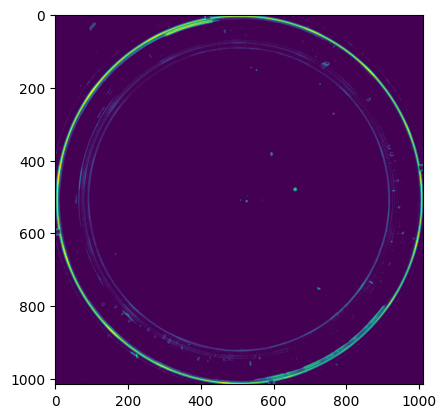

In [327]:
x_min = 25
x_max = 1040
y_min = 695
y_max = 1705

#cropping: done with numpy array indices
crop = gray[x_min:x_max, y_min:y_max] 
plt.imshow(crop)
#cv2.imwrite(image_dir + "test_crop.png", crop)


In [328]:
#combine into one
current_dir = image_dir + FormatFileName(file) + "/"
os.mkdir(current_dir)

cap = cv2.VideoCapture(data_dir + file)

#cut first 6 seconds
frames_in_six_secs = fps * 6
frame_num = 0
while frame_num < frames_in_six_secs:
    ret, frame = cap.read()
    frame_num += 1

file_num = 1
while (file_num < frames_in_min):
    ret, frame = cap.read()

    if not ret:
        break

    #GRAYSCALE
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    #cropping: done with numpy array indices
    crop = gray[x_min:x_max, y_min:y_max]

    #save final image
    cv2.imwrite(current_dir + FormatFileName(file) + GetNumberString(file_num) + ".png", crop)
    file_num += 1
    

print("Number of images: " + str(file_num))
cap.release()
cv2.destroyAllWindows()

Number of images: 1800
